# Statistical Inference: Parameter Estimation Guide

This notebook demonstrates how to use the custom `numstats.estimation` module to perform point and interval estimation on real-world datasets. We will cover estimation for:
1. Population Mean (Known & Unknown $\sigma$)
2. Population Variance
3. Population Proportion

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Importing custom estimation functions
from numstats.estimation import (
    sample_variance,
    confidence_interval_mean_known_std,
    confidence_interval_mean_unknown_std,
    confidence_interval_variance,
    confidence_interval_proportion
)

# Setting up plot style for professional look
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams["figure.figsize"] = (10, 5)

---
## 1. Estimating Population Mean (Known Standard Deviation)
### Case Study: Factory Machine Quality Control
A beverage factory fills bottles with soda. The filling machine has a known historical population standard deviation of $\sigma = 5$ ml. We take a sample of 15 bottles to verify if the machine is properly calibrated around the desired mean.

In [ ]:
# Sample of 15 bottles (measured in milliliters)
bottle_sample = [498, 502, 505, 495, 499, 501, 503, 497, 500, 502, 496, 504, 499, 501, 498]
known_sigma = 5.0
alpha = 0.05  # 95% Confidence Level

sample_mean = sum(bottle_sample) / len(bottle_sample)
ci_lower, ci_upper = confidence_interval_mean_known_std(bottle_sample, known_sigma, alpha)

print(f"Sample Mean: {sample_mean:.2f} ml")
print(f"95% Confidence Interval for the Mean: [{ci_lower:.2f} ml, {ci_upper:.2f} ml]")

Sample Mean: 500.00 ml
95% Confidence Interval for the Mean: [497.47 ml, 502.53 ml]


**Business Interpretation:** We are 95% confident that the true average volume of all bottles filled by this machine lies between the calculated lower and upper bounds. Since the target of 500 ml falls inside this interval, the machine does not require recalibration.

---
## 2. Estimating Population Mean (Unknown Standard Deviation)
### Case Study: E-commerce Website Load Times
An e-commerce platform monitors page load times (in seconds). We do not know the population standard deviation, so we estimate it directly from our sample using `sample_variance`. We will use a small sample ($n \le 30$) which triggers the Student's t-distribution.

In [ ]:
# Load times of 10 random users (in seconds)
load_times = [2.1, 2.5, 3.1, 1.9, 2.4, 2.8, 3.5, 2.2, 2.6, 2.9]
alpha_99 = 0.01  # 99% Confidence Level

mean_load = sum(load_times) / len(load_times)
ci_mean_low, ci_mean_up = confidence_interval_mean_unknown_std(load_times, alpha_99)

print(f"Sample Mean Load Time: {mean_load:.2f} seconds")
print(f"99% Confidence Interval: [{ci_mean_low:.2f} s, {ci_mean_up:.2f} s]")

Sample Mean Load Time: 2.60 seconds
99% Confidence Interval: [2.10 s, 3.10 s]


### Visualizing the Mean Confidence Interval

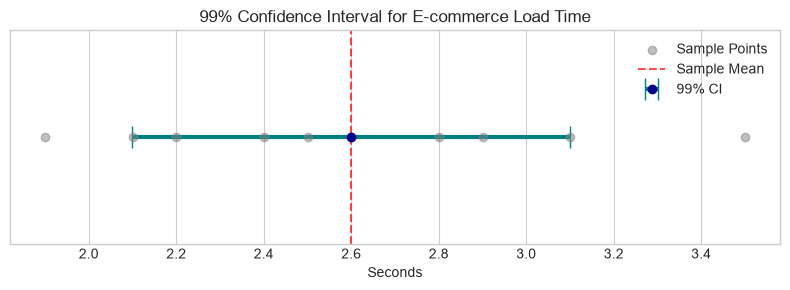

In [ ]:
plt.figure(figsize=(8, 3))
plt.errorbar(mean_load, 1, xerr=[[mean_load - ci_mean_low], [ci_mean_up - mean_load]], 
             fmt='o', color='darkblue', ecolor='teal', elinewidth=3, capsize=8, label='99% CI')
plt.scatter(load_times, np.ones(len(load_times)), color='gray', alpha=0.5, zorder=2, label='Sample Points')
plt.axvline(mean_load, color='red', linestyle='--', alpha=0.7, label='Sample Mean')
plt.title('99% Confidence Interval for E-commerce Load Time')
plt.xlabel('Seconds')
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. Estimating Population Variance
### Case Study: Financial Investment Risk Analysis
In finance, variance and standard deviation represent volatility (risk). An investor analyzes the daily returns of a specific stock over 20 days to estimate the true market volatility using the Chi-Square distribution.

In [ ]:
# Daily returns of a stock (percentage change)
stock_returns = [1.2, -0.5, 2.3, -1.1, 0.4, 1.8, -2.0, 0.9, 1.5, -0.2, 
                 1.1, 0.7, -1.4, 2.1, 0.3, -0.9, 1.6, 0.5, -0.4, 1.2]

var_est = sample_variance(stock_returns)
ci_var_low, ci_var_up = confidence_interval_variance(stock_returns, alpha=0.05)

print(f"Sample Variance (Point Estimate): {var_est:.4f}")
print(f"95% Confidence Interval for Variance: [{ci_var_low:.4f}, {ci_var_up:.4f}]")
print(f"95% Confidence Interval for Volatility (Std Dev): [{np.sqrt(ci_var_low):.4f}%, {np.sqrt(ci_var_up):.4f}%]")

Sample Variance (Point Estimate): 1.4700
95% Confidence Interval for Variance: [0.8502, 3.1359]
95% Confidence Interval for Volatility (Std Dev): [0.9220%, 1.7708%]


---
## 4. Estimating Population Proportion
### Case Study: App Marketing Conversion Rate
A marketing team runs an A/B test campaign. Out of a sample of users, they track who purchased the subscription (`"Converted"`) vs who did not (`"Not Converted"`). They need to estimate the total conversion rate of the market.

In [ ]:
# Marketing sample survey results
marketing_data = ["Converted", "Not Converted", "Not Converted", "Converted", "Converted",
                  "Not Converted", "Converted", "Not Converted", "Not Converted", "Converted",
                  "Converted", "Not Converted", "Converted", "Converted", "Not Converted",
                  "Not Converted", "Converted", "Not Converted", "Converted", "Converted"]

target = "Converted"
ci_prop_low, ci_prop_up = confidence_interval_proportion(marketing_data, target, alpha=0.05)
sample_prop = marketing_data.count(target) / len(marketing_data)

print(f"Sample Conversion Rate: {sample_prop * 100:.1f}%")
print(f"95% Confidence Interval for Market Conversion: [{ci_prop_low*100:.1f}%, {ci_prop_up*100:.1f}%]")

Sample Conversion Rate: 55.0%
95% Confidence Interval for Market Conversion: [33.2%, 76.8%]


### Visualizing Conversion Trajectory
Let's see how the proportion stabilizes as sample size increases, adding depth to our analysis.

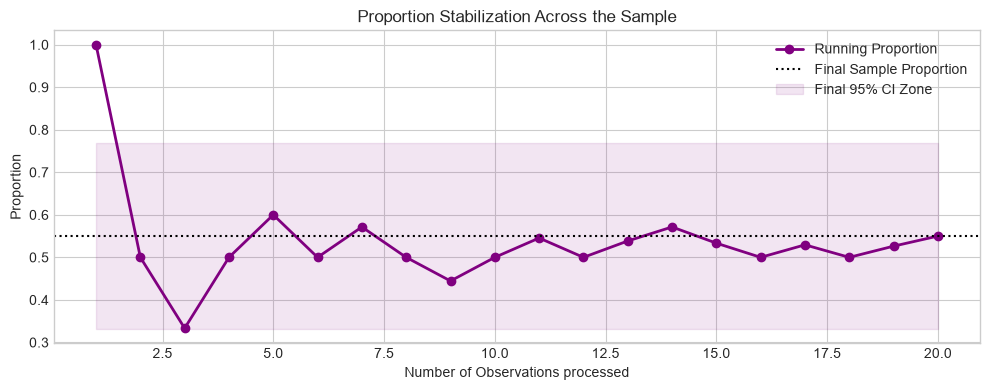

In [ ]:
cumulative_proportions = []
success_count = 0

for i, outcome in enumerate(marketing_data, 1):
    if outcome == target:
        success_count += 1
    cumulative_proportions.append(success_count / i)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(marketing_data) + 1), cumulative_proportions, marker='o', color='purple', linewidth=2, label='Running Proportion')
plt.axhline(sample_prop, color='black', linestyle=':', label='Final Sample Proportion')
plt.fill_between(range(1, len(marketing_data) + 1), ci_prop_low, ci_prop_up, color='purple', alpha=0.1, label='Final 95% CI Zone')
plt.title('Proportion Stabilization Across the Sample')
plt.xlabel('Number of Observations processed')
plt.ylabel('Proportion')
plt.legend()
plt.tight_layout()
plt.show()